# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

In [2]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [3]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)
test_data = EMNISTDataProvider('test', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/Users/alicegraham/Documents/GitHub/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/alicegraham/Documents/GitHub/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


# L2 Penalty #

In [14]:
# L2 PENALTY

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

weights_penalty = L2Penalty(coefficient=0.001)
biases_penalty = L2Penalty(coefficient=0.001)

# Create model with THREE hidden layers
l2_model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty, biases_penalty=biases_penalty), # first hidden layer
    ReluLayer(),

    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty, biases_penalty=biases_penalty), # second hidden layer
    ReluLayer(),

    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty, biases_penalty=biases_penalty), # third hidden layer
    ReluLayer(),

    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=weights_penalty, biases_penalty=biases_penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
l2_stats, l2_keys, l2_run_time, l2_fig_1, l2_ax_1, l2_fig_2, l2_ax_2, l2_grad_plot, l2_grad_ax = train_model_and_plot_stats(
    l2_model, error, learning_rule, train_data, test_data, num_epochs, stats_interval, notebook=True)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 17.0s to complete
    error(train)=1.39e+00, acc(train)=6.16e-01, error(valid)=1.40e+00, acc(valid)=6.11e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 19.0s to complete
    error(train)=1.15e+00, acc(train)=6.74e-01, error(valid)=1.16e+00, acc(valid)=6.72e-01


...

Epoch 98: 7.6s to complete
    error(train)=3.65e-01, acc(train)=8.79e-01, error(valid)=4.59e-01, acc(valid)=8.50e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 7.8s to complete
    error(train)=3.70e-01, acc(train)=8.76e-01, error(valid)=4.68e-01, acc(valid)=8.45e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 7.3s to complete
    error(train)=3.63e-01, acc(train)=8.81e-01, error(valid)=4.60e-01, acc(valid)=8.50e-01


# Label Smoothing #

In [40]:
# Label Smoothing

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

smoothed_train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=True)

# Create model with THREE hidden layers
smoothed_model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),

    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),

    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),

    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
smoothed_stats, smoothed_keys, smoothed_run_time, smoothed_fig_1, smoothed_ax_1, smoothed_fig_2, smoothed_ax_2, smoothed_grad_plot, smoothed_grad_ax = train_model_and_plot_stats(
    smoothed_model, error, learning_rule, smoothed_train_data, valid_data, num_epochs, stats_interval, notebook=True)

KeysView(NpzFile '/Users/alicegraham/Documents/GitHub/mlpractical/data/emnist-train.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 19.7s to complete
    error(train)=1.89e+00, acc(train)=6.36e-01, error(valid)=1.43e+00, acc(valid)=6.33e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 98: 5.6s to complete
    error(train)=1.02e+00, acc(train)=9.09e-01, error(valid)=5.63e-01, acc(valid)=8.49e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 12.9s to complete
    error(train)=1.02e+00, acc(train)=9.09e-01, error(valid)=5.63e-01, acc(valid)=8.51e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 6.7s to complete
    error(train)=1.02e+00, acc(train)=9.10e-01, error(valid)=5.60e-01, acc(valid)=8.51e-01


# PLOT #

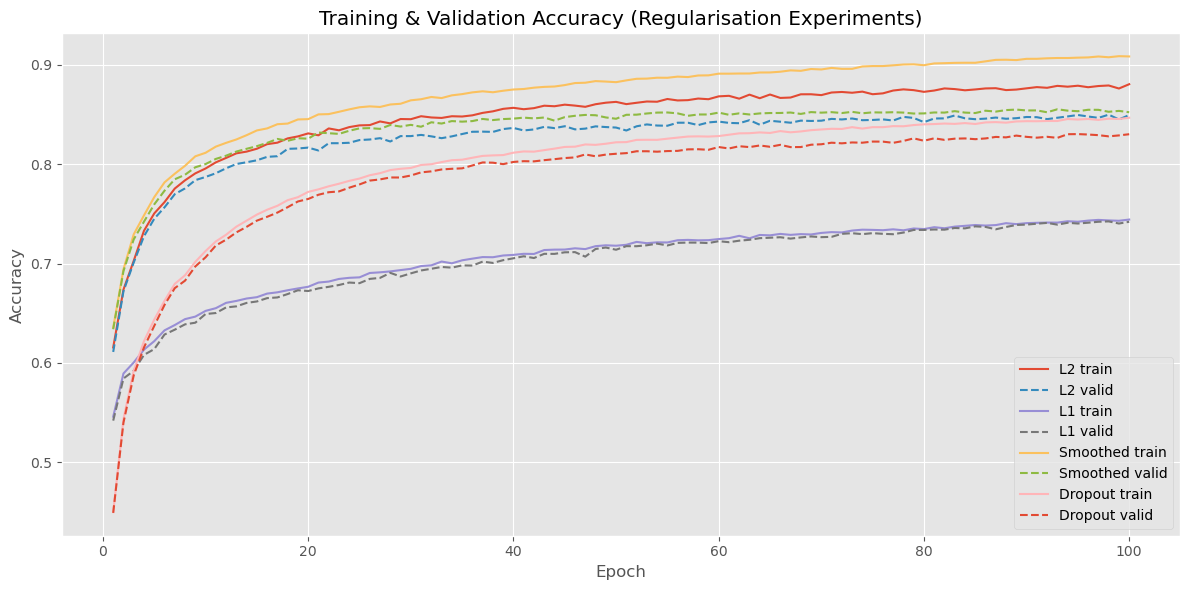

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
ax = plt.gca()

# ----- L2 -----
ax.plot(np.arange(1, l2_stats.shape[0]) * stats_interval,
        l2_stats[1:, l2_keys['acc(train)']],
        label="L2 train")
ax.plot(np.arange(1, l2_stats.shape[0]) * stats_interval,
        l2_stats[1:, l2_keys['acc(valid)']],
        label="L2 valid", linestyle="--")

# ----- L1 -----
ax.plot(np.arange(1, l1_stats.shape[0]) * stats_interval,
        l1_stats[1:, l1_keys['acc(train)']],
        label="L1 train")
ax.plot(np.arange(1, l1_stats.shape[0]) * stats_interval,
        l1_stats[1:, l1_keys['acc(valid)']],
        label="L1 valid", linestyle="--")

# ----- Smoothed -----
ax.plot(np.arange(1, smoothed_stats.shape[0]) * stats_interval,
        smoothed_stats[1:, smoothed_keys['acc(train)']],
        label="Smoothed train")
ax.plot(np.arange(1, smoothed_stats.shape[0]) * stats_interval,
        smoothed_stats[1:, smoothed_keys['acc(valid)']],
        label="Smoothed valid", linestyle="--")

# ----- Dropout -----
ax.plot(np.arange(1, dropout_stats.shape[0]) * stats_interval,
        dropout_stats[1:, dropout_keys['acc(train)']],
        label="Dropout train")
ax.plot(np.arange(1, dropout_stats.shape[0]) * stats_interval,
        dropout_stats[1:, dropout_keys['acc(valid)']],
        label="Dropout valid", linestyle="--")

ax.set_title("Training & Validation Accuracy (Regularisation Experiments)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


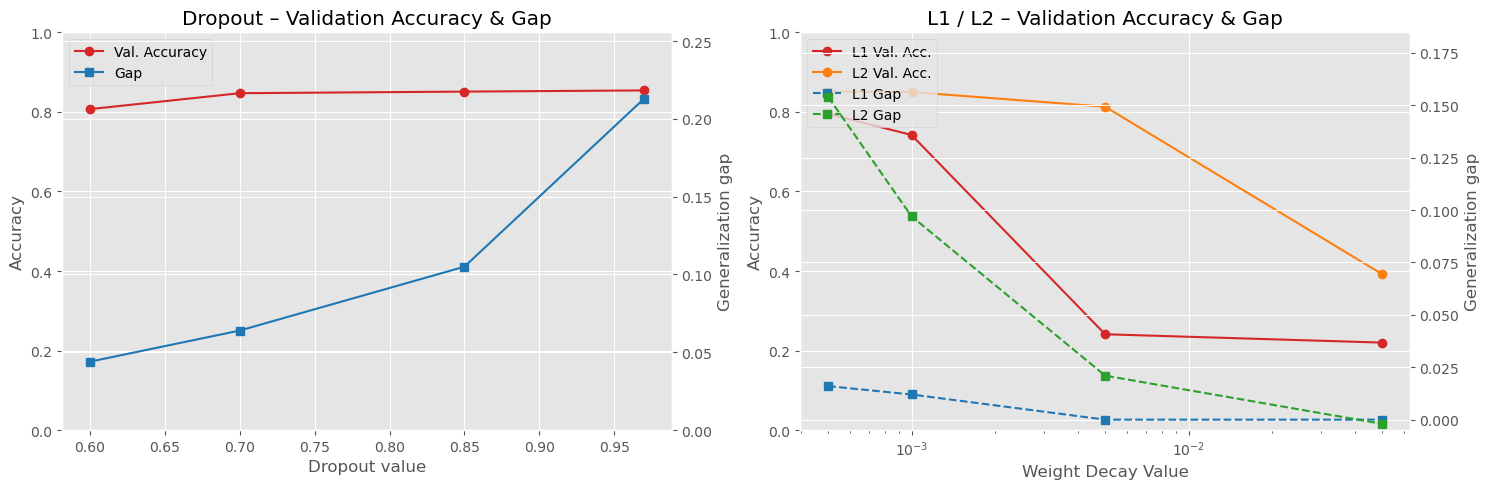

In [34]:
import matplotlib.pyplot as plt

# --------------------------
# DATA FROM THE TABLE
# --------------------------

# Dropout
dropout_rates = [0.6, 0.7, 0.85, 0.97]
dropout_val_acc = [0.807, 0.847, 0.851, 0.854]
dropout_val_err = [0.593, 0.509, 0.434, 0.457]
dropout_train_err = [0.549, 0.445, 0.329, 0.244]

dropout_gap = [v - t for v, t in zip(dropout_val_err, dropout_train_err)]

# L1
l1_lambdas = [0.0005, 0.001, 0.005, 0.05]
l1_val_acc = [0.795, 0.742, 0.241, 0.220]
l1_val_err = [0.658, 0.895, 3.850, 3.850]
l1_train_err = [0.642, 0.883, 3.850, 3.850]

l1_gap = [v - t for v, t in zip(l1_val_err, l1_train_err)]

# L2
l2_lambdas = [0.0005, 0.001, 0.005, 0.05]
l2_val_acc = [0.851, 0.850, 0.813, 0.392]
l2_val_err = [0.460, 0.460, 0.607, 2.256]
l2_train_err = [0.306, 0.363, 0.586, 2.258]

l2_gap = [v - t for v, t in zip(l2_val_err, l2_train_err)]

# --------------------------
# PLOTTING
# --------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# =====================================
#  Subplot 1: Dropout
# =====================================
ax1 = axes[0]
ax1.plot(dropout_rates, dropout_val_acc, marker='o', label="Val. Accuracy", color="tab:red")
ax1.set_xlabel("Dropout value")
ax1.set_ylabel("Accuracy")
ax1.tick_params(axis='y')
ax1.set_ylim(0, 1.0)
ax1.grid(True)

# Second y-axis (gap)
ax1b = ax1.twinx()
ax1b.plot(dropout_rates, dropout_gap, marker='s', label="Gap", color="tab:blue")
ax1b.set_ylabel("Generalization gap")
ax1b.tick_params(axis='y')
ax1b.set_ylim(0, max(dropout_gap) * 1.2)

lns1 = ax1.get_lines() + ax1b.get_lines()
labs1 = [l.get_label() for l in lns1]
ax1.legend(lns1, labs1, loc="upper left")

ax1.set_title("Dropout – Validation Accuracy & Gap")

# =====================================
#  Subplot 2: L1 & L2
# =====================================
ax2 = axes[1]
ax2.plot(l1_lambdas, l1_val_acc, marker='o', label="L1 Val. Acc.", color="tab:red")
ax2.plot(l2_lambdas, l2_val_acc, marker='o', label="L2 Val. Acc.", color="tab:orange")
ax2.set_xlabel("Weight Decay Value")
ax2.set_ylabel("Accuracy")
ax2.tick_params(axis='y')
ax2.set_xscale("log")
ax2.set_ylim(0, 1.0)
ax2.grid(True)

# Second axis (gap)
ax2b = ax2.twinx()
ax2b.plot(l1_lambdas, l1_gap, marker='s', label="L1 Gap", color="tab:blue", linestyle="--")
ax2b.plot(l2_lambdas, l2_gap, marker='s', label="L2 Gap", color="tab:green", linestyle="--")
ax2b.set_ylabel("Generalization gap")
ax2b.tick_params(axis='y')
ax2b.set_ylim(-0.005, max(max(l1_gap), max(l2_gap)) * 1.2)

# combine legends
lns2 = ax2.get_lines() + ax2b.get_lines()
labs2 = [l.get_label() for l in lns2]
ax2.legend(lns2, labs2, loc="upper left")

ax2.set_title("L1 / L2 – Validation Accuracy & Gap")

plt.tight_layout()
plt.show()


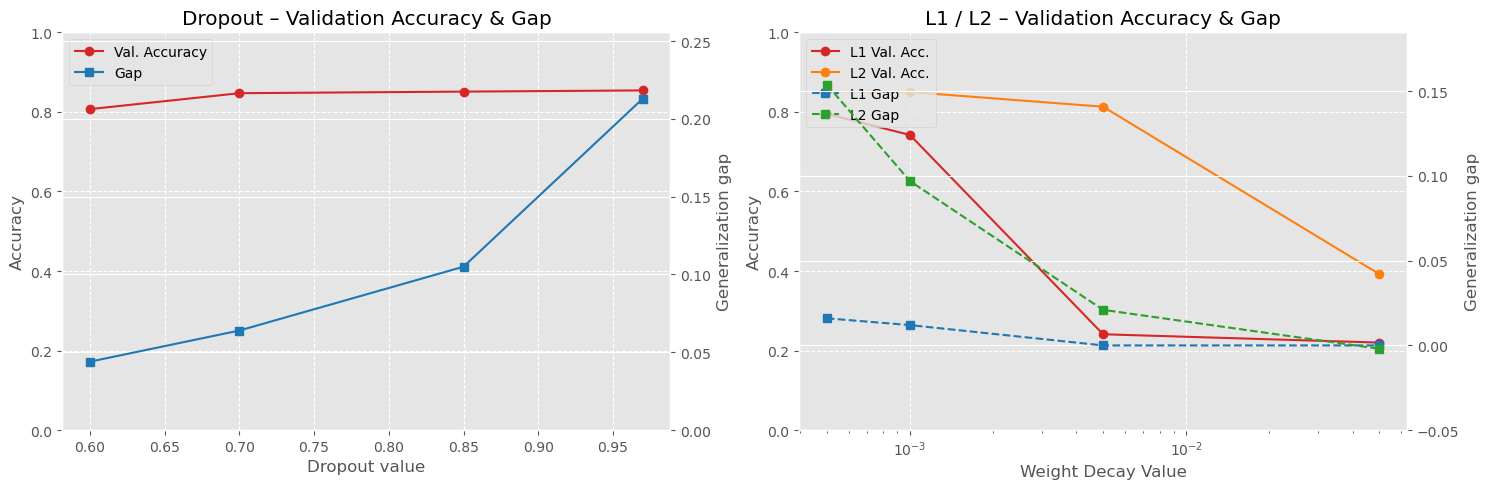

In [39]:
import matplotlib.pyplot as plt

# --------------------------
# DATA
# --------------------------
dropout_rates = [0.6, 0.7, 0.85, 0.97]
dropout_val_acc = [0.807, 0.847, 0.851, 0.854]
dropout_val_err = [0.593, 0.509, 0.434, 0.457]
dropout_train_err = [0.549, 0.445, 0.329, 0.244]
dropout_gap = [v - t for v, t in zip(dropout_val_err, dropout_train_err)]

l1_lambdas = [0.0005, 0.001, 0.005, 0.05]
l1_val_acc = [0.795, 0.742, 0.241, 0.220]
l1_val_err = [0.658, 0.895, 3.850, 3.850]
l1_train_err = [0.642, 0.883, 3.850, 3.850]
l1_gap = [v - t for v, t in zip(l1_val_err, l1_train_err)]

l2_lambdas = [0.0005, 0.001, 0.005, 0.05]
l2_val_acc = [0.851, 0.850, 0.813, 0.392]
l2_val_err = [0.460, 0.460, 0.607, 2.256]
l2_train_err = [0.306, 0.363, 0.586, 2.258]
l2_gap = [v - t for v, t in zip(l2_val_err, l2_train_err)]

# --------------------------
# PLOTTING
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Subplot 1: Dropout ----
ax1 = axes[0]
ax1.plot(dropout_rates, dropout_val_acc, marker='o', label="Val. Accuracy", color="tab:red")
ax1.set_xlabel("Dropout value")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.0)
ax1.grid(True, linestyle='--')

ax1b = ax1.twinx()
ax1b.plot(dropout_rates, dropout_gap, marker='s', label="Gap", color="tab:blue")
ax1b.set_ylabel("Generalization gap")
ax1b.set_ylim(0, max(dropout_gap) * 1.2)

# Legend
lns1 = ax1.get_lines() + ax1b.get_lines()
labs1 = [l.get_label() for l in lns1]
ax1.legend(lns1, labs1, loc="upper left")
ax1.set_title("Dropout – Validation Accuracy & Gap")

# ---- Subplot 2: L1 / L2 ----
ax2 = axes[1]
ax2.plot(l1_lambdas, l1_val_acc, marker='o', label="L1 Val. Acc.", color="tab:red")
ax2.plot(l2_lambdas, l2_val_acc, marker='o', label="L2 Val. Acc.", color="tab:orange")
ax2.set_xlabel("Weight Decay Value")
ax2.set_ylabel("Accuracy")
ax2.set_xscale("log")
ax2.set_ylim(0, 1.0)
ax2.grid(True, linestyle='--')

ax2b = ax2.twinx()
ax2b.plot(l1_lambdas, l1_gap, marker='s', label="L1 Gap", color="tab:blue", linestyle="--")
ax2b.plot(l2_lambdas, l2_gap, marker='s', label="L2 Gap", color="tab:green", linestyle="--")
ax2b.set_ylabel("Generalization gap")
ax2b.set_ylim(-0.05, max(max(l1_gap), max(l2_gap)) * 1.2)

# Combine legends
lns2 = ax2.get_lines() + ax2b.get_lines()
labs2 = [l.get_label() for l in lns2]
ax2.legend(lns2, labs2, loc="upper left")
ax2.set_title("L1 / L2 – Validation Accuracy & Gap")

plt.tight_layout()
plt.show()
